In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## REVISION POINTS
- What problem does ResNet solve? (Vanishing gradient in deep networks)
- Why are skip connections useful?
- Why use BatchNorm in ResNet blocks?

In [2]:
# Data transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False,
                           download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


In [3]:
# -----------------------------
# RESNET BLOCK DEFINITION
# -----------------------------


class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResNetBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip connection - Ensures dimensions match
        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.skip(x)  # Shortcut path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity  # Adding the shortcut
        return F.relu(out)


In [4]:
# -----------------------------
# RESNET MODEL DEFINITION
# -----------------------------


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7,
                               stride=2, padding=3)  # 28x28 → 14x14
        self.bn1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(3, 2, 1)  # Downsampling

        # ResNet layers
        self.layer1 = nn.Sequential(ResNetBlock(64, 64), ResNetBlock(64, 64))
        self.layer2 = nn.Sequential(ResNetBlock(
            64, 128, stride=2), ResNetBlock(128, 128))
        self.layer3 = nn.Sequential(ResNetBlock(
            128, 256, stride=2), ResNetBlock(256, 256))
        self.layer4 = nn.Sequential(ResNetBlock(
            256, 512, stride=2), ResNetBlock(512, 512))

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # Global Average Pooling
        # Final fully connected layer
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ResNet18().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
# Training function


def train(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

In [7]:
train(model, train_loader, criterion, optimizer)

Epoch [1/5], Loss: 0.1415
Epoch [2/5], Loss: 0.0645
Epoch [3/5], Loss: 0.0480
Epoch [4/5], Loss: 0.0381
Epoch [5/5], Loss: 0.0377


In [8]:
# Testing function


def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy on test data: {100 * correct / total:.2f}%')


In [9]:

test(model, test_loader)

Accuracy on test data: 98.91%


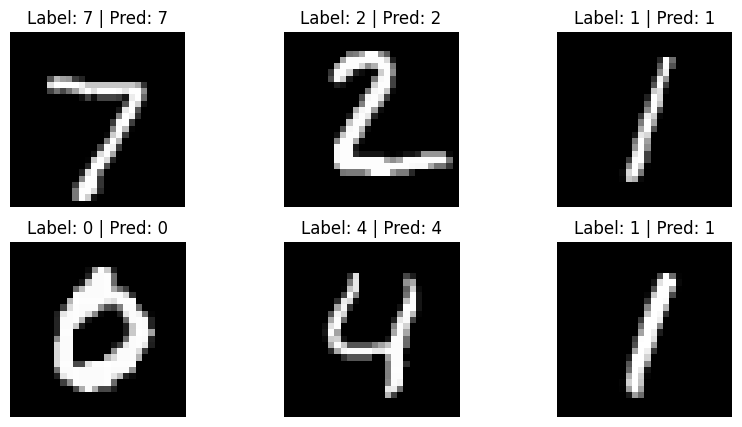

In [10]:
# -----------------------------
# VISUALIZATION OF PREDICTIONS
# -----------------------------


def visualize_predictions(model, test_loader):
    model.eval()
    data_iter = iter(test_loader)
    images, labels = next(data_iter)

    with torch.no_grad():
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs, 1)

    plt.figure(figsize=(10, 5))
    for idx in range(6):
        plt.subplot(2, 3, idx + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')
        plt.title(f'Label: {labels[idx]} | Pred: {predicted[idx].item()}')
        plt.axis('off')
    plt.show()


visualize_predictions(model, test_loader)